# Exploration of Uf01.bin Volumetric Data

Investigate the structure and properties of the volumetric data stored in the Uf01.bin binary file.


## 1. Import Required Libraries

Import NumPy for numerical operations and Matplotlib for visualization.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import os

## 2. Load Binary File Data

Load the binary file using `np.fromfile()` with dtype '<f4' (32-bit floats) and reshape into a 3D array with dimensions (z, y, x).


In [3]:
# Set the path to the data directory
data_path = os.path.join("..", "data", "raw")
filename = "Uf01.bin"
filepath = os.path.join(data_path, filename)

# Load the binary file and reshape to (z, y, x) dimensions
vol = np.fromfile(filepath, dtype='<f4').reshape((100, 500, 500))

print(f"Successfully loaded {filename}")
print(f"Data shape: {vol.shape}")


Successfully loaded Uf01.bin
Data shape: (100, 500, 500)


## 3. Inspect Data Structure and Properties

Display the shape, dtype, size, min/max values, and memory usage of the loaded volumetric data.


In [4]:
print("=" * 50)
print("Data Structure and Properties")
print("=" * 50)
print(f"Shape:          {vol.shape}")
print(f"Data type:      {vol.dtype}")
print(f"Total elements: {vol.size:,}")
print(f"Memory usage:   {vol.nbytes / 1024**2:.2f} MB")
print(f"\nValue Range:")
print(f"  Minimum:      {vol.min():.6f}")
print(f"  Maximum:      {vol.max():.6f}")
print(f"  Range:        {vol.max() - vol.min():.6f}")


Data Structure and Properties
Shape:          (100, 500, 500)
Data type:      float32
Total elements: 25,000,000
Memory usage:   95.37 MB

Value Range:
  Minimum:      -56.667465
  Maximum:      49.029739
  Range:        105.697205


## 4. Visualize Data Statistics

Calculate and display statistics such as mean, median, standard deviation, and create histograms of the data distribution.



Data Statistics
Mean:              2.586713
Median:            2.404340
Standard Deviation: 9.070271
Variance:          82.269829


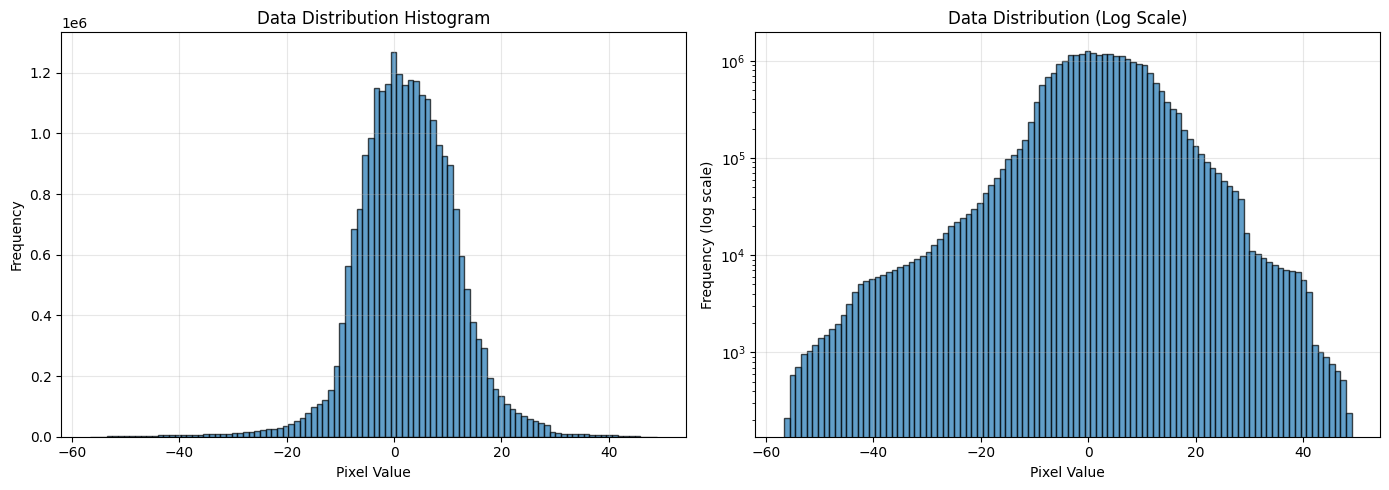

In [5]:
print("\n" + "=" * 50)
print("Data Statistics")
print("=" * 50)
print(f"Mean:              {vol.mean():.6f}")
print(f"Median:            {np.median(vol):.6f}")
print(f"Standard Deviation: {vol.std():.6f}")
print(f"Variance:          {vol.var():.6f}")

# Create a histogram of the data distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(vol.flatten(), bins=100, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Pixel Value')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Data Distribution Histogram')
axes[0].grid(True, alpha=0.3)

# Log scale histogram
axes[1].hist(vol.flatten(), bins=100, edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Pixel Value')
axes[1].set_ylabel('Frequency (log scale)')
axes[1].set_yscale('log')
axes[1].set_title('Data Distribution (Log Scale)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 5. Explore Spatial Dimensions

Extract and visualize 2D slices from different planes (axial, coronal, sagittal) to understand the spatial structure of the volume.


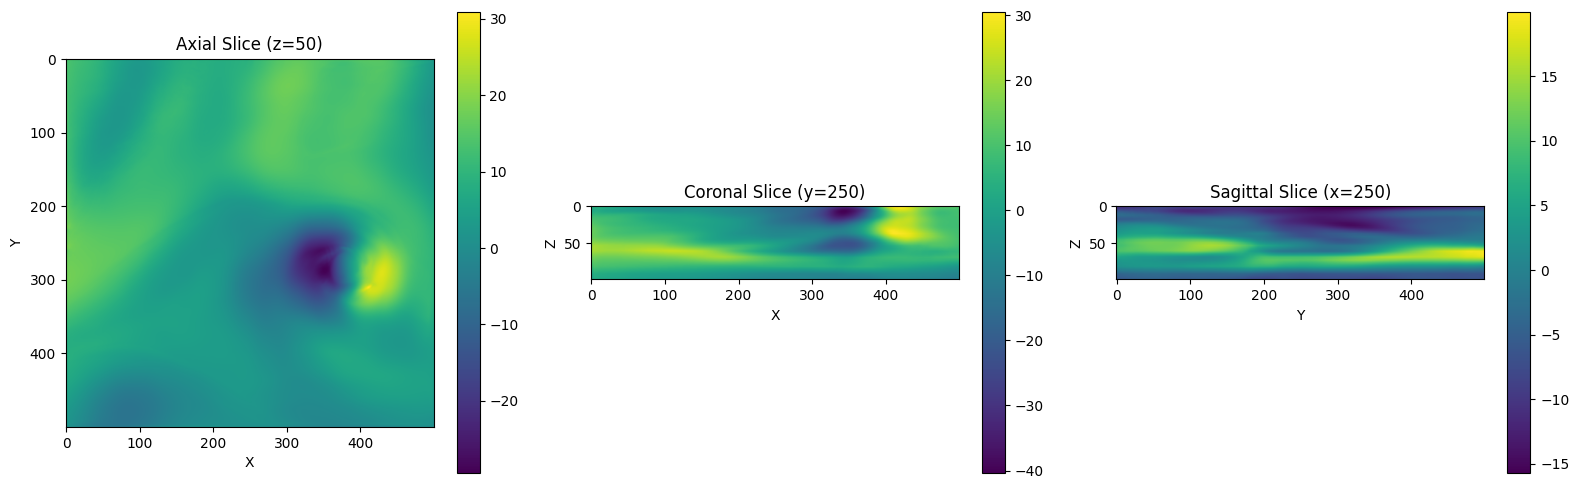

In [6]:
# Extract slices from the middle of each dimension
z_slice_idx = vol.shape[0] // 2  # Middle axial slice
y_slice_idx = vol.shape[1] // 2  # Middle coronal slice
x_slice_idx = vol.shape[2] // 2  # Middle sagittal slice

# Extract the slices
axial_slice = vol[z_slice_idx, :, :]      # (y, x)
coronal_slice = vol[:, y_slice_idx, :]    # (z, x)
sagittal_slice = vol[:, :, x_slice_idx]   # (z, y)

# Visualize the three orthogonal slices
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Axial slice (z=middle)
im0 = axes[0].imshow(axial_slice, cmap='viridis')
axes[0].set_title(f'Axial Slice (z={z_slice_idx})', fontsize=12)
axes[0].set_xlabel('X')
axes[0].set_ylabel('Y')
plt.colorbar(im0, ax=axes[0])

# Coronal slice (y=middle)
im1 = axes[1].imshow(coronal_slice, cmap='viridis')
axes[1].set_title(f'Coronal Slice (y={y_slice_idx})', fontsize=12)
axes[1].set_xlabel('X')
axes[1].set_ylabel('Z')
plt.colorbar(im1, ax=axes[1])

# Sagittal slice (x=middle)
im2 = axes[2].imshow(sagittal_slice, cmap='viridis')
axes[2].set_title(f'Sagittal Slice (x={x_slice_idx})', fontsize=12)
axes[2].set_xlabel('Y')
axes[2].set_ylabel('Z')
plt.colorbar(im2, ax=axes[2])

plt.tight_layout()
plt.show()
